# Avocado Prices — Share Phase

Build the five visualizations for the retail-client deliverable, using the small aggregate tables
produced in the Analyze phase (`data/summary/`). Palette: blue = conventional, orange = organic,
used consistently across every chart.

## Setup

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import os

SUMMARY_DIR = "../data/summary"
PROC_DIR = "../data/processed"
IMG_DIR = "../images"
os.makedirs(IMG_DIR, exist_ok=True)

BLUE = "#2a78d6"
ORANGE = "#eb6834"
INK_PRIMARY = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
GRID = "#e1e0d9"
BASELINE = "#c3c2b7"
SURFACE = "#fcfcfb"

plt.rcParams.update({
    "font.family": "Segoe UI", "text.color": INK_PRIMARY, "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY, "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 12,
})

def clean_axes(ax, hide_y=False):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(not hide_y)
    if hide_y:
        ax.yaxis.set_visible(False)
    ax.spines["bottom"].set_color(BASELINE)
    ax.tick_params(length=0)
    ax.set_axisbelow(True)

## 1. Average price by type

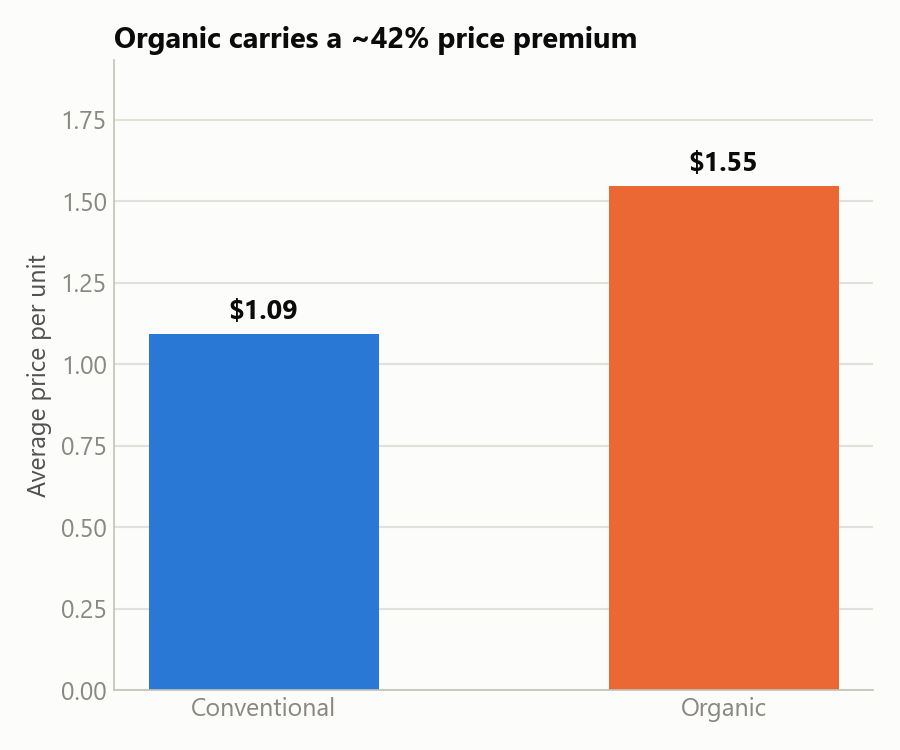

In [2]:
pbt = pd.read_csv(os.path.join(SUMMARY_DIR, "price_by_type.csv"), index_col=0).loc[["conventional", "organic"]]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(["Conventional", "Organic"], pbt["mean"], width=0.5, color=[BLUE, ORANGE])
for b, v in zip(bars, pbt["mean"]):
    ax.text(b.get_x() + b.get_width()/2, v + 0.03, f"${v:.2f}", ha="center", va="bottom",
             fontsize=13, color=INK_PRIMARY, fontweight="bold")
clean_axes(ax)
ax.set_ylabel("Average price per unit")
ax.set_ylim(0, pbt["mean"].max() * 1.25)
ax.yaxis.grid(True, color=GRID, linewidth=1)
ax.set_title("Organic carries a ~42% price premium", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "01_price_by_type.png"), dpi=150)
plt.show()

## 2. Seasonality

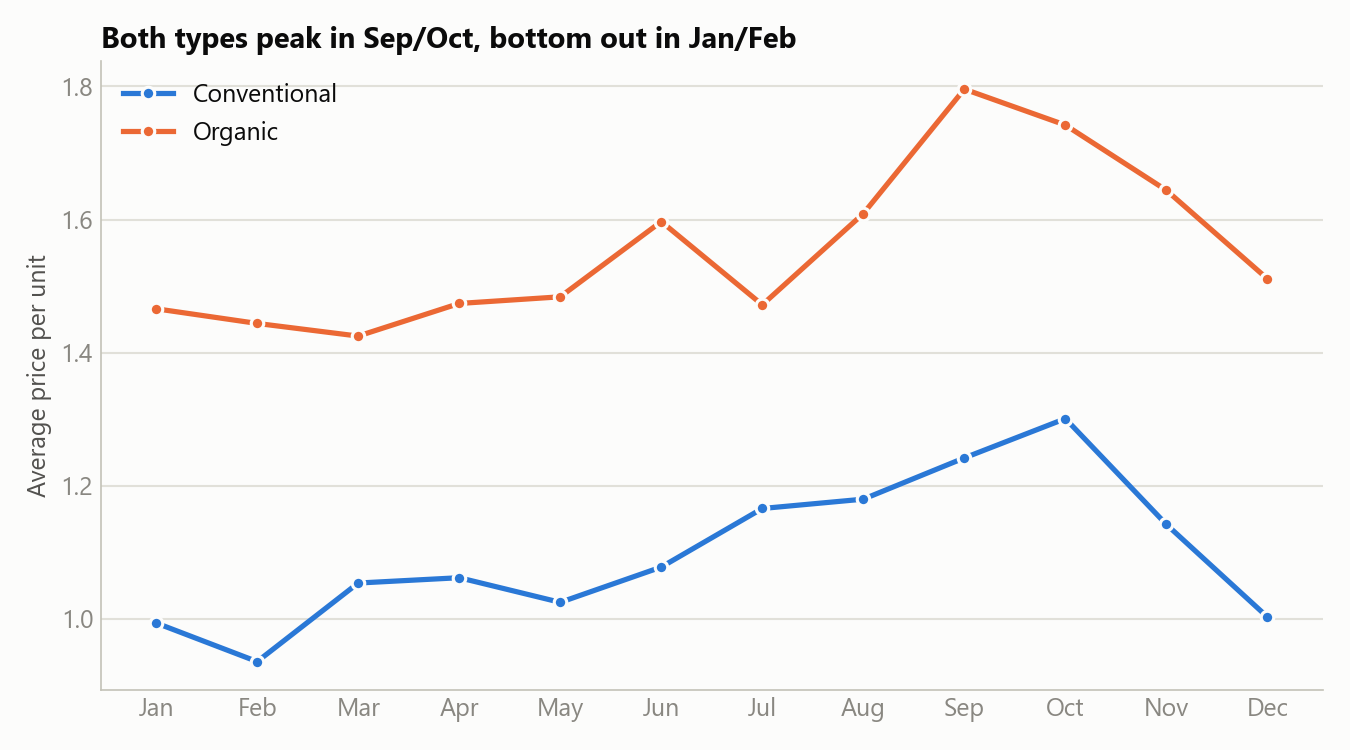

In [3]:
seas = pd.read_csv(os.path.join(SUMMARY_DIR, "seasonal_price.csv"), index_col=0)
MONTHS = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1,13), seas["conventional"], color=BLUE, linewidth=2.5, marker="o", markersize=6,
        markerfacecolor=BLUE, markeredgecolor=SURFACE, markeredgewidth=1.5, label="Conventional")
ax.plot(range(1,13), seas["organic"], color=ORANGE, linewidth=2.5, marker="o", markersize=6,
        markerfacecolor=ORANGE, markeredgecolor=SURFACE, markeredgewidth=1.5, label="Organic")
ax.set_xticks(range(1,13)); ax.set_xticklabels(MONTHS)
clean_axes(ax)
ax.yaxis.grid(True, color=GRID, linewidth=1)
ax.set_ylabel("Average price per unit")
ax.set_title("Both types peak in Sep/Oct, bottom out in Jan/Feb", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "02_seasonality.png"), dpi=150)
plt.show()

## 3. Price trend over time

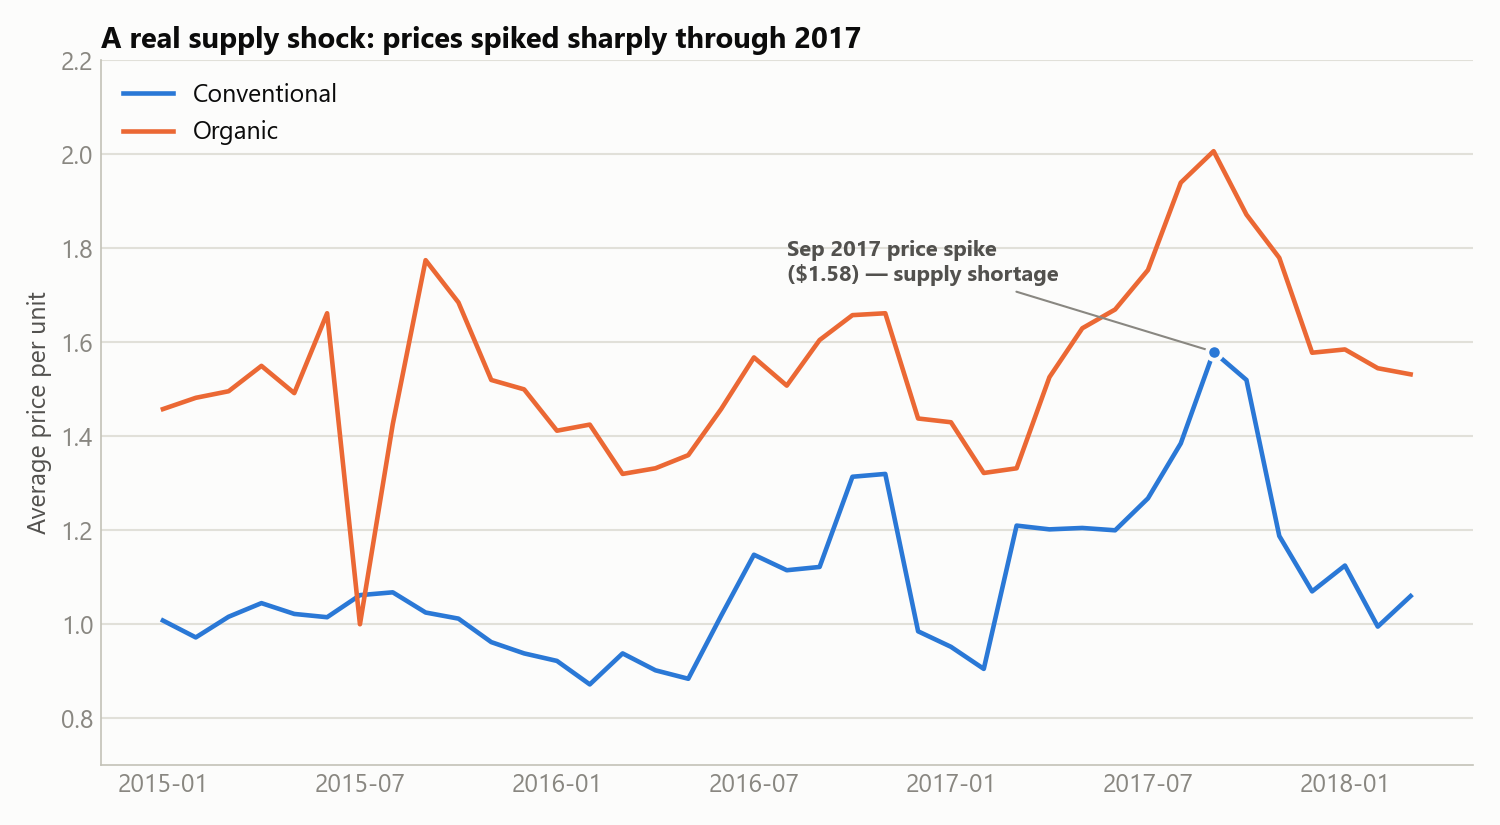

In [4]:
trend = pd.read_csv(os.path.join(SUMMARY_DIR, "price_trend_monthly.csv"), index_col=0)
x = range(len(trend))

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(x, trend["conventional"], color=BLUE, linewidth=2.2, label="Conventional")
ax.plot(x, trend["organic"], color=ORANGE, linewidth=2.2, label="Organic")
peak_idx = trend["conventional"].idxmax()
peak_pos = list(trend.index).index(peak_idx)
peak_val = trend["conventional"].max()
ax.scatter([peak_pos], [peak_val], s=50, color=BLUE, zorder=5, edgecolor=SURFACE, linewidth=2)
ax.annotate("Sep 2017 price spike\n($1.58) - supply shortage", xy=(peak_pos, peak_val),
            xytext=(peak_pos-13, peak_val+0.15), fontsize=10.5, color=INK_SECONDARY, fontweight="bold",
            arrowprops=dict(arrowstyle="-", color=INK_MUTED, lw=1))
tick_idx = list(range(0, len(trend), 6))
ax.set_xticks(tick_idx)
ax.set_xticklabels([trend.index[i] for i in tick_idx], rotation=0)
clean_axes(ax)
ax.yaxis.grid(True, color=GRID, linewidth=1)
ax.set_ylabel("Average price per unit")
ax.set_ylim(0.7, 2.2)
ax.set_title("A real supply shock: prices spiked sharply through 2017", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "03_price_trend.png"), dpi=150)
plt.show()

Note the odd flat dip to exactly $1.00 for organic in mid-2015 — the data-quality artifact documented in the Analyze phase, not a real price event.

## 4. Regional price variation

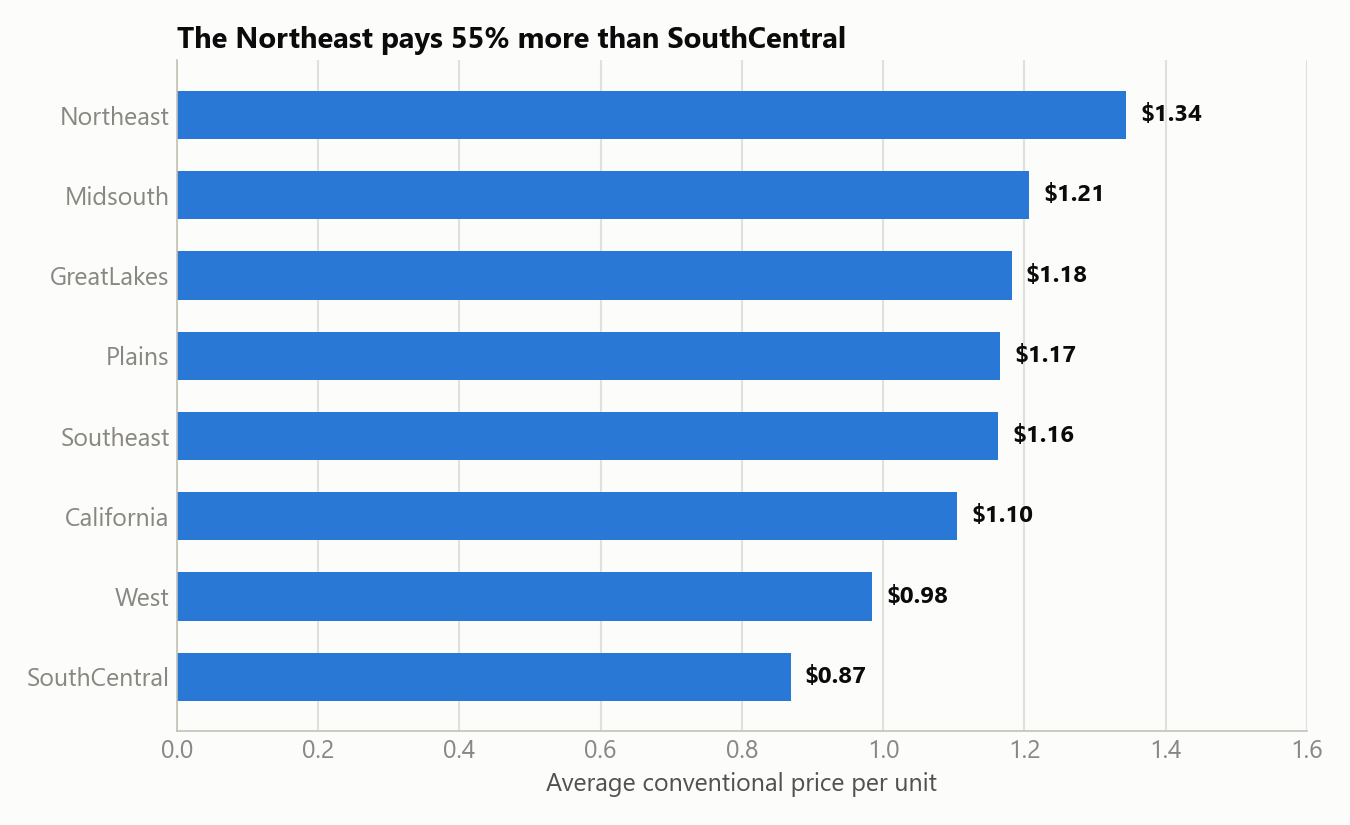

In [5]:
reg = pd.read_csv(os.path.join(SUMMARY_DIR, "regional_price.csv"), index_col=0).sort_values("conventional")

fig, ax = plt.subplots(figsize=(9, 5.5))
y = range(len(reg))
ax.barh(y, reg["conventional"], color=BLUE, height=0.6)
for i, v in enumerate(reg["conventional"]):
    ax.text(v + 0.02, i, f"${v:.2f}", va="center", fontsize=11.5, color=INK_PRIMARY, fontweight="bold")
ax.set_yticks(list(y)); ax.set_yticklabels(reg.index)
ax.set_xlim(0, 1.6); ax.set_xlabel("Average conventional price per unit")
clean_axes(ax)
ax.xaxis.grid(True, color=GRID, linewidth=1)
ax.set_title("The Northeast pays 55% more than SouthCentral", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "04_regional_price.png"), dpi=150)
plt.show()

## 5. Price vs. volume

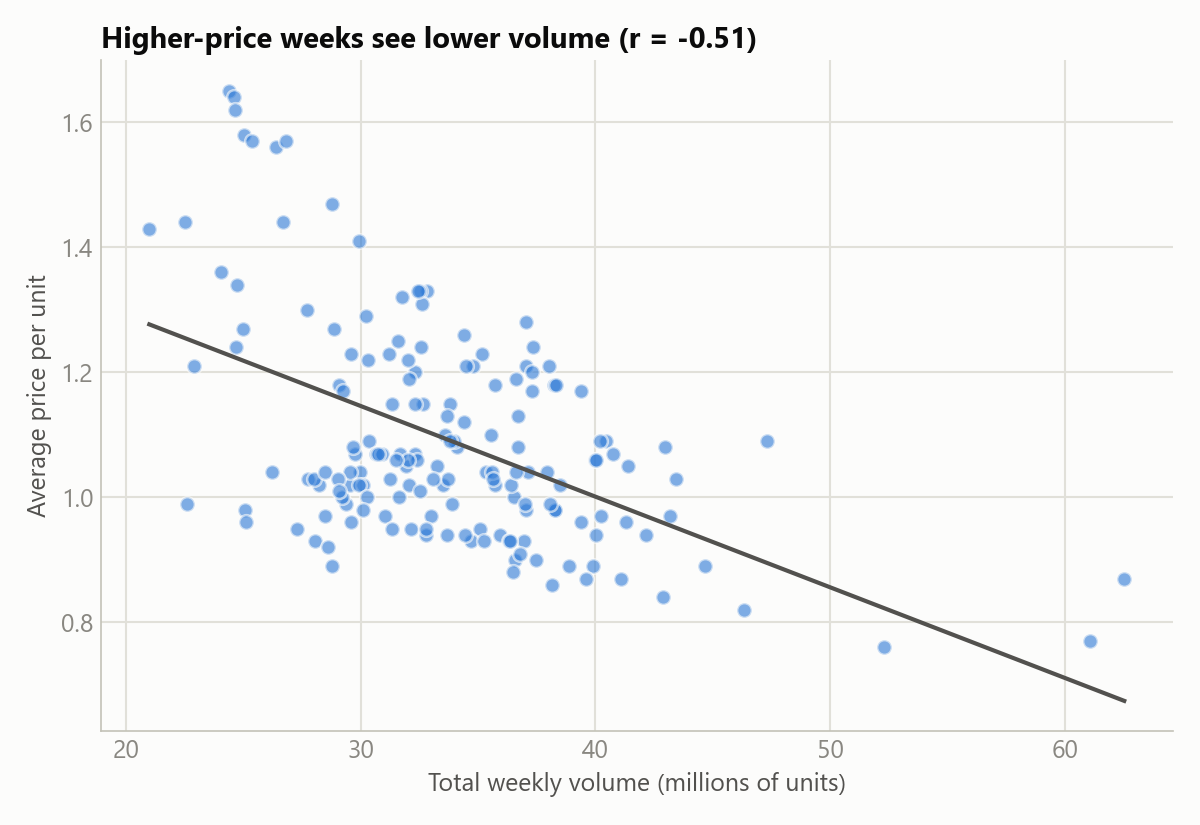

In [6]:
df = pd.read_parquet(os.path.join(PROC_DIR, "avocado_clean.parquet"))
nat_conv = df[(df["region_tier"] == "national") & (df["type"] == "conventional")]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(nat_conv["total_volume"]/1e6, nat_conv["average_price"], s=50, color=BLUE, alpha=0.6,
           edgecolor=SURFACE, linewidth=1.2, zorder=3)
z = np.polyfit(nat_conv["total_volume"]/1e6, nat_conv["average_price"], 1)
xs = np.linspace((nat_conv["total_volume"]/1e6).min(), (nat_conv["total_volume"]/1e6).max(), 50)
ax.plot(xs, np.polyval(z, xs), color=INK_SECONDARY, linewidth=2, zorder=4)
clean_axes(ax)
ax.xaxis.grid(True, color=GRID, linewidth=1); ax.yaxis.grid(True, color=GRID, linewidth=1)
ax.set_xlabel("Total weekly volume (millions of units)"); ax.set_ylabel("Average price per unit")
ax.set_title("Higher-price weeks see lower volume (r = -0.51)", fontsize=14,
              color=INK_PRIMARY, fontweight="bold", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(IMG_DIR, "05_price_vs_volume.png"), dpi=150)
plt.show()

## Summary

Seasonal, regional, and demand-driven price patterns are all clearly visible in this data, plus
a real 2017 supply-shock event — a solid evidence base for a retail client's pricing and
inventory strategy. See [`docs/05_share.md`](../docs/05_share.md) for the full write-up.